# Street Graph Exploration — urbanroamvqa

Build, validate, and visualize the `StreetGraph` used by the roaming VQA dagspace.
Goals:
1. Load Cyclomedia Manhattan metadata and build a KNN street graph
2. Inspect graph statistics (degree distribution, distance distribution, connectivity)
3. Validate face-to-neighbor resolution and arrival-face logic
4. Visualize the graph on a map
5. Produce and cache a graph for later pipeline use

In [46]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dagspaces.urbanroamvqa.graph.street_graph import (
    StreetGraph, Neighbor, FACE_BEARING_DEG,
    _normalize_bearing, _bearing_diff, _face_for_bearing,
)
from dagspaces.urbanroamvqa.graph.builder import (
    build_street_graph, _build_knn_graph, _haversine_m, _bearing_deg,
)
from dagspaces.urbanroamvqa.samplers.seed_sampler import sample_walk_seeds

## 1. Load recording metadata

In [47]:
PARQUET_PATH = "../../data/cyclomedia/recordings_manhattan_2025_md.parquet"

raw = pd.read_parquet(PARQUET_PATH)
print(f"Raw recordings: {len(raw):,} rows, {raw.columns.tolist()}")

# Rename to match builder expectations
meta = raw.rename(columns={
    "imageId": "recording_id",
    "lat": "latitude",
    "lon": "longitude",
    "yawDegrees": "yaw_deg",
})[["recording_id", "latitude", "longitude", "yaw_deg"]].copy()

meta.head()

Raw recordings: 540,959 rows, ['imageId', 'lon', 'lat', 'recordedAt', 'productType', 'orientation', 'yawDegrees', 'orientationPrecision', 'yawPrecisionDegrees', 'recorderDirection', 'statePlaneX', 'statePlaneY', 'locationSRS', 'height', 'heightSystem', 'groundLevelOffset', 'latitudePrecision', 'longitudePrecision', 'heightPrecision', 'year', 'panoramaTileSchema', 'tileSchema', 'hasDepthMap', 'isAuthorized']


,recording_id,latitude,longitude,yaw_deg
0,W0DBPTNW,40.682931,-74.008453,20625.793075
1,W0DBPTNX,40.682936,-74.008512,20625.793075
2,W0DBPTNY,40.682924,-74.008568,20625.793075
3,W0EGPC2O,40.682934,-74.008436,20625.793075
4,W0EGPC2P,40.682941,-74.008493,20625.793075


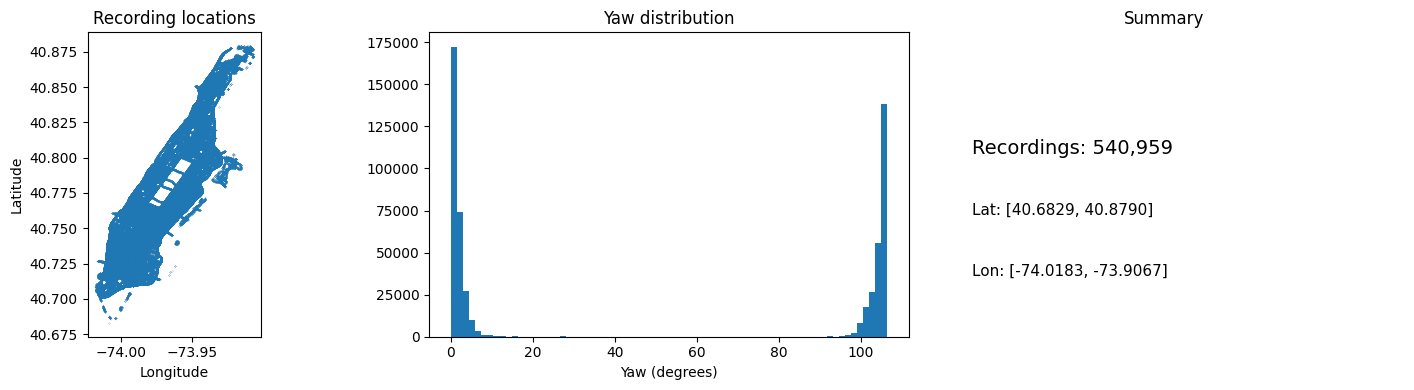

In [48]:
# Quick sanity: spatial extent and yaw distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(meta["longitude"], meta["latitude"], s=0.01, alpha=0.3)
axes[0].set_title("Recording locations")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_aspect("equal")

axes[1].hist(meta["yaw_deg"] % 360, bins=72, edgecolor="none")
axes[1].set_title("Yaw distribution")
axes[1].set_xlabel("Yaw (degrees)")

axes[2].text(0.1, 0.6, f"Recordings: {len(meta):,}", fontsize=14, transform=axes[2].transAxes)
axes[2].text(0.1, 0.4, f"Lat: [{meta['latitude'].min():.4f}, {meta['latitude'].max():.4f}]", fontsize=11, transform=axes[2].transAxes)
axes[2].text(0.1, 0.2, f"Lon: [{meta['longitude'].min():.4f}, {meta['longitude'].max():.4f}]", fontsize=11, transform=axes[2].transAxes)
axes[2].axis("off")
axes[2].set_title("Summary")

plt.tight_layout()
plt.show()

## 2. Build KNN street graph

Start with a small subset to iterate quickly, then scale up. The builder expects
a parquet with `recording_id`, `latitude`, `longitude`, `yaw_deg` columns.

In [49]:
# Build graph on a geographic subset first (e.g. a ~20-block area in Midtown)
# Roughly: 40.748-40.758 lat, -73.990 to -73.978 lon (Times Square area)
SUBSET_BOUNDS = {
    "lat_min": 40.748, "lat_max": 40.758,
    "lon_min": -73.990, "lon_max": -73.978,
}

subset = meta[
    (meta["latitude"].between(SUBSET_BOUNDS["lat_min"], SUBSET_BOUNDS["lat_max"])) &
    (meta["longitude"].between(SUBSET_BOUNDS["lon_min"], SUBSET_BOUNDS["lon_max"]))
].copy().reset_index(drop=True)

print(f"Subset recordings: {len(subset):,}")

# Save to temp parquet so builder can read it
SUBSET_PARQUET = "/tmp/flaneur_subset_recordings.parquet"
subset.to_parquet(SUBSET_PARQUET)

Subset recordings: 10,744


In [50]:
from types import SimpleNamespace

graph_cfg = SimpleNamespace(
    k_neighbors=10,
    max_radius_m=50.0,
    bearing_tolerance_deg=45.0,
    precomputed_path=None,
)

graph = build_street_graph(SUBSET_PARQUET, graph_cfg, use_osmnx=False)

n_nodes = len(graph.adjacency)
degrees = [len(nbs) for nbs in graph.adjacency.values()]
print(f"Nodes: {n_nodes:,}")
print(f"Degree — mean: {np.mean(degrees):.1f}, median: {np.median(degrees):.1f}, "
      f"min: {np.min(degrees)}, max: {np.max(degrees)}")
print(f"Isolated nodes (degree 0): {sum(1 for d in degrees if d == 0)}")

[street_graph] Loading metadata from /tmp/flaneur_subset_recordings.parquet
[street_graph] Building graph for 10744 unique recordings (k=10, radius=50.0m)
[street_graph] Graph built: 10744 nodes, avg 10.0 neighbors
Nodes: 10,744
Degree — mean: 10.0, median: 10.0, min: 10, max: 10
Isolated nodes (degree 0): 0


## 3. Graph statistics

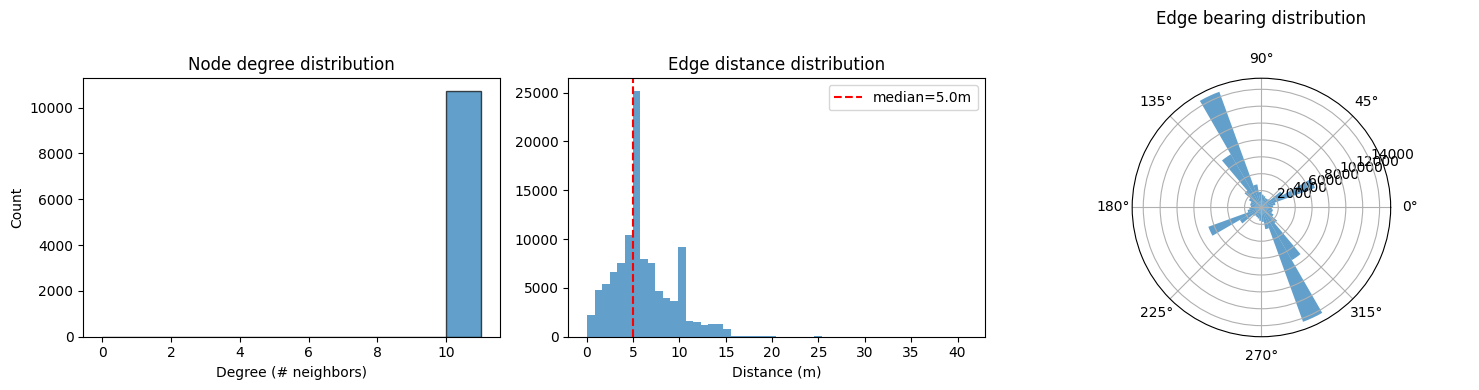

In [51]:
# Degree and edge-distance distributions
all_dists = [nb.distance_m for nbs in graph.adjacency.values() for nb in nbs]
all_bearings = [nb.bearing_deg for nbs in graph.adjacency.values() for nb in nbs]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(degrees, bins=range(0, max(degrees) + 2), edgecolor="black", alpha=0.7)
axes[0].set_title("Node degree distribution")
axes[0].set_xlabel("Degree (# neighbors)")
axes[0].set_ylabel("Count")

axes[1].hist(all_dists, bins=50, edgecolor="none", alpha=0.7)
axes[1].set_title("Edge distance distribution")
axes[1].set_xlabel("Distance (m)")
axes[1].axvline(np.median(all_dists), color="red", ls="--", label=f"median={np.median(all_dists):.1f}m")
axes[1].legend()

# Bearing as polar histogram
ax_polar = fig.add_subplot(1, 3, 3, projection="polar")
bearing_rad = np.deg2rad(all_bearings)
ax_polar.hist(bearing_rad, bins=36, edgecolor="none", alpha=0.7)
ax_polar.set_title("Edge bearing distribution", pad=20)
axes[2].axis("off")  # hide the cartesian axis

plt.tight_layout()
plt.show()

## 4. Validate face resolution logic

Test that `resolve_face_to_neighbor` correctly maps face choices to neighbors,
and that `arrival_face` computes the forward-facing direction at the destination.

In [52]:
# Pick a well-connected sample node
sample_id = max(graph.adjacency, key=lambda k: len(graph.adjacency[k]))
sample_nbs = graph.neighbors(sample_id)
sample_yaw = graph.yaw_degrees[sample_id]
sample_coords = graph.coords[sample_id]

print(f"Sample node: {sample_id}")
print(f"  Coords: ({sample_coords[0]:.6f}, {sample_coords[1]:.6f})")
print(f"  Yaw: {sample_yaw:.1f} deg (normalized: {sample_yaw % 360:.1f})")
print(f"  Neighbors: {len(sample_nbs)}")
print()

# Show each face's absolute bearing and which neighbor it resolves to
for face, offset in FACE_BEARING_DEG.items():
    abs_bearing = _normalize_bearing(sample_yaw + offset)
    nb = graph.resolve_face_to_neighbor(sample_id, face, graph_cfg.bearing_tolerance_deg)
    if nb:
        print(f"  Face {face} -> bearing {abs_bearing:6.1f} -> {nb.recording_id} "
              f"(dist={nb.distance_m:.1f}m, bearing={nb.bearing_deg:.1f})")
    else:
        print(f"  Face {face} -> bearing {abs_bearing:6.1f} -> NO MATCH within tolerance")

Sample node: W0D5LAA3
  Coords: (40.748860, -73.989618)
  Yaw: 20625.5 deg (normalized: 105.5)
  Neighbors: 10

  Face F -> bearing  105.5 -> W0ECIPZR (dist=3.3m, bearing=117.3)
  Face R -> bearing  195.5 -> NO MATCH within tolerance
  Face B -> bearing  285.5 -> W0D5LAA2 (dist=5.0m, bearing=301.5)
  Face L -> bearing   15.5 -> NO MATCH within tolerance


In [53]:
# Validate arrival_face: if we walk from A -> B, the arrival face at B
# should point roughly away from A (i.e., forward along the direction of travel)
print("Arrival face validation (sample transitions):\n")

for nb in sample_nbs[:5]:
    af = graph.arrival_face(sample_id, nb.recording_id)
    available = graph.available_faces(af)
    
    # Reverse check: the arrival face's absolute bearing at dest should roughly
    # align with the bearing FROM source TO dest
    dest_yaw = graph.yaw_degrees.get(nb.recording_id, 0)
    af_abs_bearing = _normalize_bearing(dest_yaw + FACE_BEARING_DEG[af])
    
    print(f"  {sample_id} -> {nb.recording_id}")
    print(f"    Travel bearing: {nb.bearing_deg:.1f}")
    print(f"    Arrival face: {af} (abs bearing at dest: {af_abs_bearing:.1f})")
    print(f"    Bearing diff (should be small): {_bearing_diff(nb.bearing_deg, af_abs_bearing):.1f}")
    print(f"    Available faces to choose: {available}")
    print()

Arrival face validation (sample transitions):

  W0D5LAA3 -> W0ECIPZQ
    Travel bearing: 313.0
    Arrival face: L (abs bearing at dest: 270.9)
    Bearing diff (should be small): 42.2
    Available faces to choose: ['F', 'R', 'B']

  W0D5LAA3 -> W0ECIPZR
    Travel bearing: 117.3
    Arrival face: F (abs bearing at dest: 105.5)
    Bearing diff (should be small): 11.8
    Available faces to choose: ['R', 'B', 'L']

  W0D5LAA3 -> W0D5LAA2
    Travel bearing: 301.5
    Arrival face: L (abs bearing at dest: 270.9)
    Bearing diff (should be small): 30.6
    Available faces to choose: ['F', 'R', 'B']

  W0D5LAA3 -> W0D5LAA4
    Travel bearing: 120.6
    Arrival face: F (abs bearing at dest: 105.5)
    Bearing diff (should be small): 15.1
    Available faces to choose: ['R', 'B', 'L']

  W0D5LAA3 -> W0ECIPZP
    Travel bearing: 308.2
    Arrival face: L (abs bearing at dest: 270.9)
    Bearing diff (should be small): 37.3
    Available faces to choose: ['F', 'R', 'B']



Arrival-face alignment across all 107,440 edges:
  Mean diff: 21.1 deg
  Median diff: 21.1 deg
  90th percentile: 36.2 deg
  Within 45 deg: 100.0%
  Within 90 deg: 100.0%


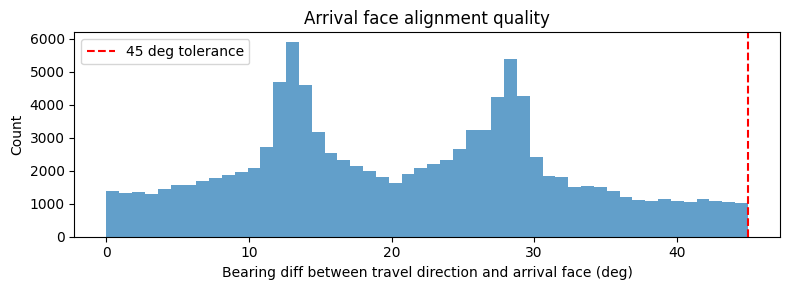

In [54]:
# Systematic check: across all edges, how well does arrival_face align with travel direction?
bearing_diffs = []
for src_id, nbs in graph.adjacency.items():
    for nb in nbs:
        af = graph.arrival_face(src_id, nb.recording_id)
        dest_yaw = graph.yaw_degrees.get(nb.recording_id, 0)
        af_abs = _normalize_bearing(dest_yaw + FACE_BEARING_DEG[af])
        bearing_diffs.append(_bearing_diff(nb.bearing_deg, af_abs))

bearing_diffs = np.array(bearing_diffs)
print(f"Arrival-face alignment across all {len(bearing_diffs):,} edges:")
print(f"  Mean diff: {bearing_diffs.mean():.1f} deg")
print(f"  Median diff: {np.median(bearing_diffs):.1f} deg")
print(f"  90th percentile: {np.percentile(bearing_diffs, 90):.1f} deg")
print(f"  Within 45 deg: {(bearing_diffs <= 45).mean():.1%}")
print(f"  Within 90 deg: {(bearing_diffs <= 90).mean():.1%}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(bearing_diffs, bins=50, edgecolor="none", alpha=0.7)
ax.axvline(45, color="red", ls="--", label="45 deg tolerance")
ax.set_xlabel("Bearing diff between travel direction and arrival face (deg)")
ax.set_ylabel("Count")
ax.set_title("Arrival face alignment quality")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Visualize the graph

Plot nodes and edges on a scatter map. Color edges by bearing to see street grid alignment.

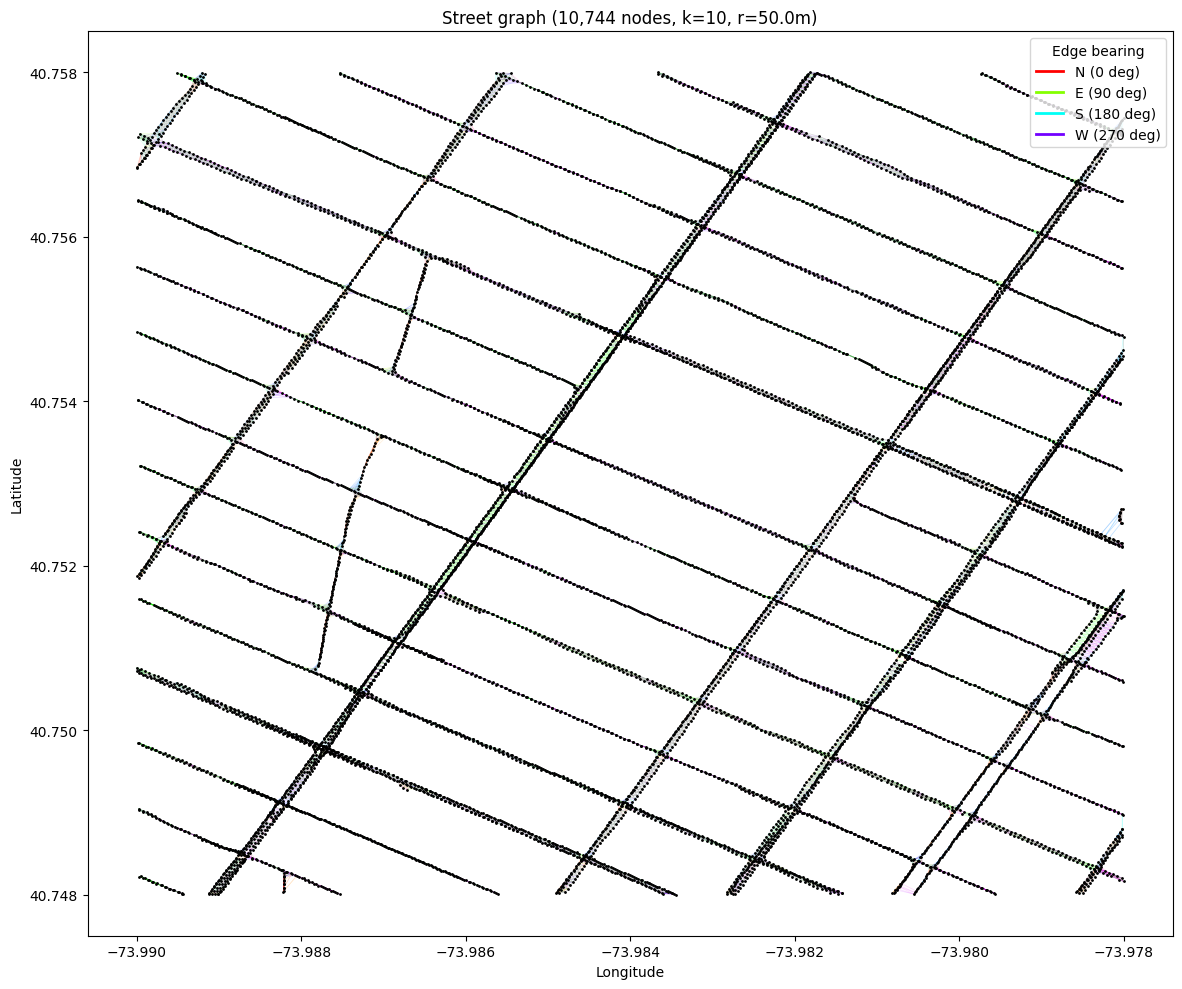

In [55]:
fig, ax = plt.subplots(figsize=(12, 10))

# Plot edges colored by bearing
cmap = plt.cm.hsv
for src_id, nbs in graph.adjacency.items():
    src_lat, src_lon = graph.coords[src_id]
    for nb in nbs:
        dst_lat, dst_lon = graph.coords[nb.recording_id]
        color = cmap(nb.bearing_deg / 360.0)
        ax.plot([src_lon, dst_lon], [src_lat, dst_lat],
                color=color, alpha=0.15, linewidth=0.5)

# Plot nodes
lats = [c[0] for c in graph.coords.values()]
lons = [c[1] for c in graph.coords.values()]
ax.scatter(lons, lats, s=1, c="black", zorder=5)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Street graph ({n_nodes:,} nodes, k={graph_cfg.k_neighbors}, r={graph_cfg.max_radius_m}m)")
ax.set_aspect("equal")

# Bearing color legend
import matplotlib.patches as mpatches
for bearing, label in [(0, "N"), (90, "E"), (180, "S"), (270, "W")]:
    ax.plot([], [], color=cmap(bearing / 360.0), linewidth=2, label=f"{label} ({bearing} deg)")
ax.legend(loc="upper right", title="Edge bearing")

plt.tight_layout()
plt.show()

## 6. Simulate a random walk

Walk the graph using random face choices to validate traversal logic end-to-end.

In [56]:
def simulate_walk(graph, start_id, max_steps=30, seed=42, tolerance=45.0):
    """Random-face walk through the graph. Returns list of (recording_id, face_chosen, distance_m)."""
    rng = np.random.default_rng(seed)
    trace = [{"recording_id": start_id, "face_chosen": None, "distance_m": 0.0,
              "lat": graph.coords[start_id][0], "lon": graph.coords[start_id][1]}]
    
    current = start_id
    arrival = "F"  # initial facing
    visited = {start_id}
    
    for step in range(max_steps):
        faces = graph.available_faces(arrival)
        rng.shuffle(faces)
        
        moved = False
        for face in faces:
            nb = graph.resolve_face_to_neighbor(current, face, tolerance)
            if nb and nb.recording_id not in visited:
                arrival = graph.arrival_face(current, nb.recording_id)
                visited.add(nb.recording_id)
                trace.append({
                    "recording_id": nb.recording_id,
                    "face_chosen": face,
                    "distance_m": nb.distance_m,
                    "lat": graph.coords[nb.recording_id][0],
                    "lon": graph.coords[nb.recording_id][1],
                })
                current = nb.recording_id
                moved = True
                break
        
        if not moved:
            print(f"  Dead end at step {step} (node {current})")
            break
    
    return pd.DataFrame(trace)

# Use seed sampler to pick a starting point
seeds = sample_walk_seeds(graph, n_walks=1, seed=0, strategy="random", min_neighbors=3)
start = seeds.iloc[0]["seed_recording_id"]
print(f"Starting walk from {start}")

walk_df = simulate_walk(graph, start, max_steps=30)
print(f"Walk length: {len(walk_df)} steps, total distance: {walk_df['distance_m'].sum():.0f}m")
walk_df

Starting walk from W0DENBXZ
  Dead end at step 8 (node W0D5IPJK)
Walk length: 9 steps, total distance: 34m


,recording_id,face_chosen,distance_m,lat,lon
0,W0DENBXZ,None,0.000000,40.753758,-73.978628
1,W0DENBY0,L,4.992509,40.753797,-73.978599
2,W0E65G5Z,F,3.548436,40.753804,-73.978558
3,W0E65G60,L,4.977471,40.753843,-73.978529
4,W0DENBY1,B,3.548672,40.753836,-73.978570
5,W0DENBY2,L,4.998999,40.753876,-73.978541
6,W0E65G61,F,3.557494,40.753882,-73.978500
7,W0E65G62,L,4.971248,40.753921,-73.978471
8,W0D5IPJK,R,3.768665,40.753888,-73.978483


/tmp/ipykernel_171249/2940129926.py:31: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/share/pierson/matt/mllmsci/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


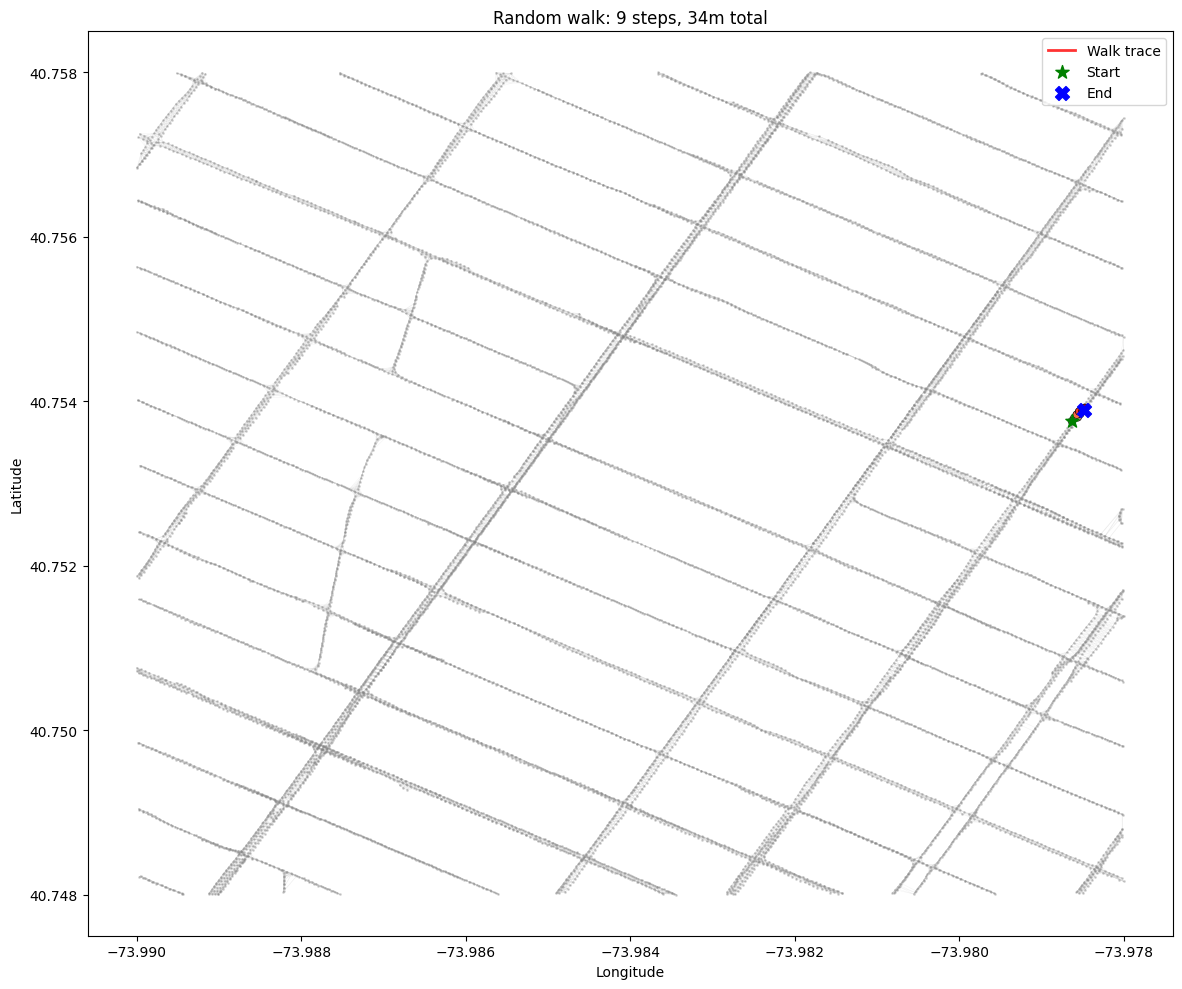

In [57]:
# Plot the walk on the graph
fig, ax = plt.subplots(figsize=(12, 10))

# Background: all edges (faint)
for src_id, nbs in graph.adjacency.items():
    src_lat, src_lon = graph.coords[src_id]
    for nb in nbs:
        dst_lat, dst_lon = graph.coords[nb.recording_id]
        ax.plot([src_lon, dst_lon], [src_lat, dst_lat], color="lightgray", alpha=0.3, linewidth=0.3)

# All nodes
all_lats = [c[0] for c in graph.coords.values()]
all_lons = [c[1] for c in graph.coords.values()]
ax.scatter(all_lons, all_lats, s=1, c="gray", alpha=0.3, zorder=3)

# Walk trace
walk_lons = walk_df["lon"].values
walk_lats = walk_df["lat"].values
ax.plot(walk_lons, walk_lats, color="red", linewidth=2, alpha=0.8, zorder=10, label="Walk trace")
ax.scatter(walk_lons, walk_lats, c=range(len(walk_df)), cmap="Reds", s=30, zorder=11, edgecolors="black", linewidths=0.5)

# Mark start and end
ax.scatter([walk_lons[0]], [walk_lats[0]], c="green", s=100, zorder=12, marker="*", label="Start")
ax.scatter([walk_lons[-1]], [walk_lats[-1]], c="blue", s=100, zorder=12, marker="X", label="End")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Random walk: {len(walk_df)} steps, {walk_df['distance_m'].sum():.0f}m total")
ax.set_aspect("equal")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Seed sampler comparison

Compare random vs. spatial-stratified sampling strategies.

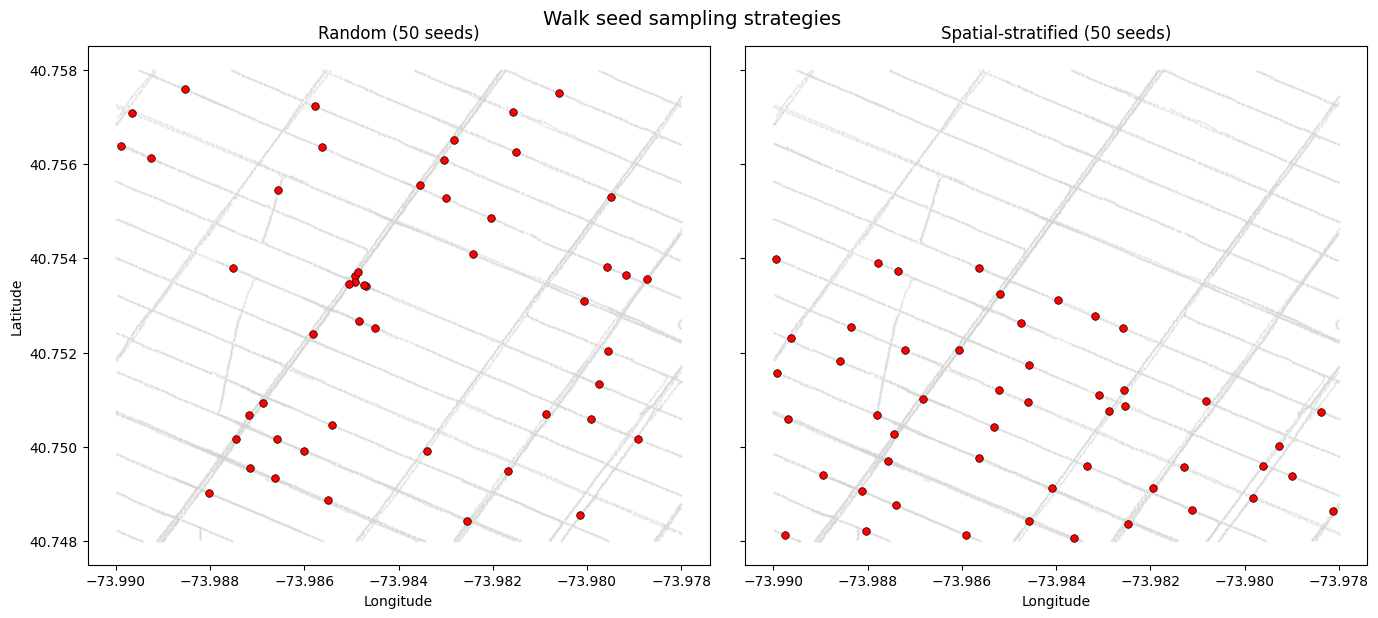

In [58]:
n_seeds = 50

seeds_random = sample_walk_seeds(graph, n_walks=n_seeds, seed=42, strategy="random", min_neighbors=2)
seeds_stratified = sample_walk_seeds(graph, n_walks=n_seeds, seed=42, strategy="spatial_stratified", min_neighbors=2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax, seeds_df, title in [
    (axes[0], seeds_random, "Random"),
    (axes[1], seeds_stratified, "Spatial-stratified"),
]:
    # Background nodes
    ax.scatter(all_lons, all_lats, s=0.5, c="lightgray", alpha=0.5)
    # Seeds
    ax.scatter(seeds_df["lon"], seeds_df["lat"], s=30, c="red", edgecolors="black", linewidths=0.5, zorder=5)
    ax.set_title(f"{title} ({len(seeds_df)} seeds)")
    ax.set_xlabel("Longitude")
    ax.set_aspect("equal")

axes[0].set_ylabel("Latitude")
plt.suptitle("Walk seed sampling strategies", fontsize=14)
plt.tight_layout()
plt.show()

## 8. Connectivity analysis

Check that the graph is well-connected enough for multi-step walks.
A walk that hits dead ends quickly indicates poor connectivity or overly tight tolerance.

  Dead end at step 15 (node W0ECL360)
  Dead end at step 10 (node W0ECL3MH)
  Dead end at step 9 (node W0E6114G)
  Dead end at step 1 (node W0E5JUTT)
  Dead end at step 13 (node W0ECNXDN)
  Dead end at step 2 (node W0E61ELO)
  Dead end at step 1 (node W0D5JCU0)
  Dead end at step 30 (node W0EQV1NJ)
  Dead end at step 23 (node W0D5JNFR)
  Dead end at step 4 (node W0DEM68U)
  Dead end at step 12 (node W0E60B0Z)
  Dead end at step 3 (node W0D5JFR7)
  Dead end at step 26 (node W0D5KVFR)
  Dead end at step 15 (node W0ED1EKX)
  Dead end at step 2 (node W0EQW7EH)
  Dead end at step 14 (node W0E61E05)
  Dead end at step 1 (node W0D5KUU1)
  Dead end at step 7 (node W0D5JFR7)
  Dead end at step 1 (node W0D5KUS5)
  Dead end at step 9 (node W0ECJA8S)
  Dead end at step 9 (node W0D5MV1F)
  Dead end at step 6 (node W0DENBW7)
  Dead end at step 11 (node W0EQVICI)
  Dead end at step 4 (node W0D5KVE1)
  Dead end at step 9 (node W0DENBVC)
  Dead end at step 4 (node W0DENC0M)
  Dead end at step 18 (node 

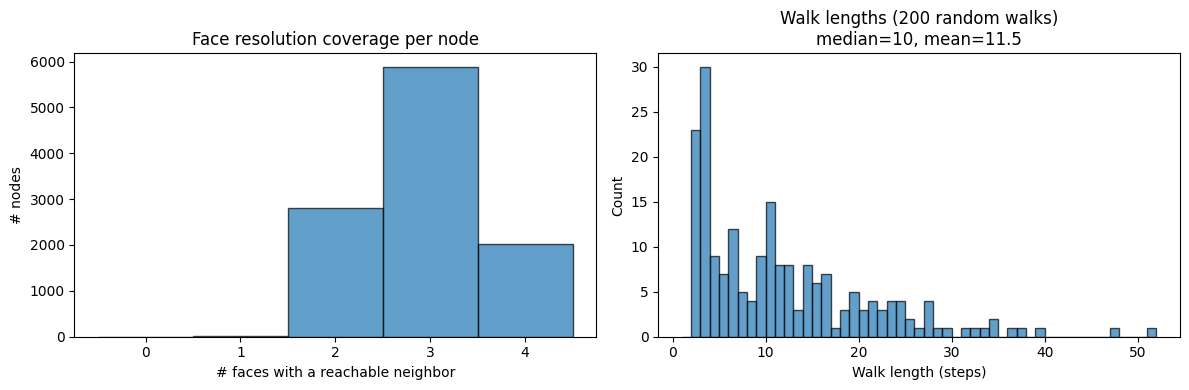

In [59]:
# Face resolution coverage: for each node, how many of the 4 faces resolve to a neighbor?
face_coverage = []
for rid in graph.adjacency:
    resolved = sum(
        1 for face in ("F", "R", "B", "L")
        if graph.resolve_face_to_neighbor(rid, face, graph_cfg.bearing_tolerance_deg) is not None
    )
    face_coverage.append(resolved)

face_coverage = np.array(face_coverage)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(face_coverage, bins=range(0, 6), edgecolor="black", alpha=0.7, align="left")
axes[0].set_xticks(range(5))
axes[0].set_xlabel("# faces with a reachable neighbor")
axes[0].set_ylabel("# nodes")
axes[0].set_title("Face resolution coverage per node")

# Run many short walks to measure typical walk lengths before dead-end
walk_lengths = []
eligible = [rid for rid, nbs in graph.adjacency.items() if len(nbs) >= 2]
rng = np.random.default_rng(123)
for i in range(200):
    start = rng.choice(eligible)
    wdf = simulate_walk(graph, start, max_steps=50, seed=i)
    walk_lengths.append(len(wdf))

# Suppress dead-end prints — redefine quietly
walk_lengths = np.array(walk_lengths)
axes[1].hist(walk_lengths, bins=range(1, walk_lengths.max() + 2), edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Walk length (steps)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Walk lengths (200 random walks)\nmedian={np.median(walk_lengths):.0f}, mean={walk_lengths.mean():.1f}")

plt.tight_layout()
plt.show()

## 9. Parameter sensitivity

How do `k_neighbors`, `max_radius_m`, and `bearing_tolerance_deg` affect graph quality?

In [60]:
# Sweep max_radius_m and k_neighbors, measure mean degree and face coverage
results = []
for k in [5, 10, 15, 20]:
    for radius in [20, 30, 50, 75, 100]:
        cfg = SimpleNamespace(k_neighbors=k, max_radius_m=radius, precomputed_path=None)
        g = build_street_graph(SUBSET_PARQUET, cfg, use_osmnx=False)
        
        degs = [len(nbs) for nbs in g.adjacency.values()]
        fc = np.mean([
            sum(1 for f in ("F","R","B","L") if g.resolve_face_to_neighbor(rid, f, 45.0) is not None)
            for rid in g.adjacency
        ])
        results.append({"k": k, "radius_m": radius, "mean_degree": np.mean(degs), "mean_face_coverage": fc})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

[street_graph] Loading metadata from /tmp/flaneur_subset_recordings.parquet
[street_graph] Building graph for 10744 unique recordings (k=5, radius=20.0m)
[street_graph] Graph built: 10744 nodes, avg 5.0 neighbors
[street_graph] Loading metadata from /tmp/flaneur_subset_recordings.parquet
[street_graph] Building graph for 10744 unique recordings (k=5, radius=30.0m)
[street_graph] Graph built: 10744 nodes, avg 5.0 neighbors
[street_graph] Loading metadata from /tmp/flaneur_subset_recordings.parquet
[street_graph] Building graph for 10744 unique recordings (k=5, radius=50.0m)
[street_graph] Graph built: 10744 nodes, avg 5.0 neighbors
[street_graph] Loading metadata from /tmp/flaneur_subset_recordings.parquet
[street_graph] Building graph for 10744 unique recordings (k=5, radius=75.0m)
[street_graph] Graph built: 10744 nodes, avg 5.0 neighbors
[street_graph] Loading metadata from /tmp/flaneur_subset_recordings.parquet
[street_graph] Building graph for 10744 unique recordings (k=5, radius=1

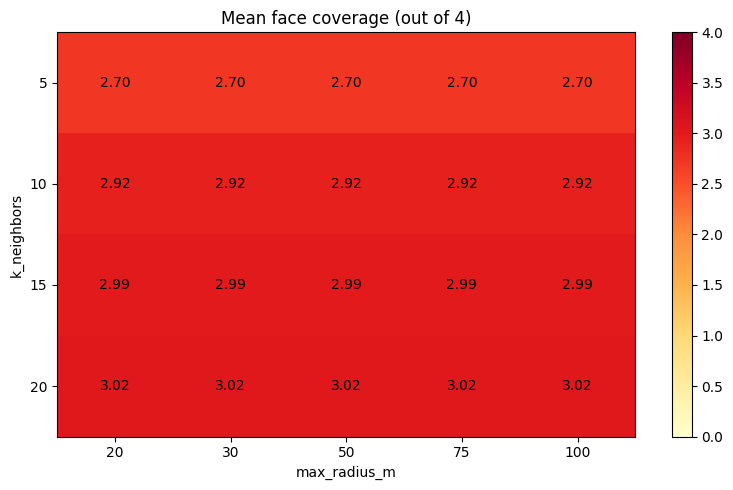

In [61]:
# Heatmap of face coverage
pivot = results_df.pivot(index="k", columns="radius_m", values="mean_face_coverage")

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto", vmin=0, vmax=4)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("max_radius_m")
ax.set_ylabel("k_neighbors")
ax.set_title("Mean face coverage (out of 4)")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i, j]:.2f}", ha="center", va="center", fontsize=10)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 10. The cross-direction problem

The real issue isn't duplication — it's that the graph connects recordings from
opposite driving directions. A walk stepping "forward" can latch onto a recording
from a vehicle going the other way, flipping perspective.

Diagnose: how often do edges connect recordings with incompatible yaws?

In [ ]:
# For each edge in the current KNN graph, check yaw compatibility:
# Is the destination's yaw aligned with the travel bearing?
yaw_compat_diffs = []
for src_id, nbs in graph.adjacency.items():
    for nb in nbs:
        dest_yaw = graph.yaw_degrees.get(nb.recording_id, 0) % 360
        travel_bearing = nb.bearing_deg
        diff = _bearing_diff(travel_bearing, dest_yaw)
        yaw_compat_diffs.append(diff)

yaw_compat_diffs = np.array(yaw_compat_diffs)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(yaw_compat_diffs, bins=60, edgecolor="none", alpha=0.7)
ax.axvline(90, color="red", ls="--", label="90° threshold")
ax.set_xlabel("Bearing diff: travel direction vs destination yaw (deg)")
ax.set_ylabel("Count")
ax.set_title("Yaw compatibility of current KNN edges")
ax.legend()

print(f"Edges with yaw diff > 90° (cross-direction): "
      f"{(yaw_compat_diffs > 90).sum():,} / {len(yaw_compat_diffs):,} "
      f"({(yaw_compat_diffs > 90).mean():.1%})")
print(f"Edges with yaw diff > 120° (clearly opposite): "
      f"{(yaw_compat_diffs > 120).sum():,} ({(yaw_compat_diffs > 120).mean():.1%})")

plt.tight_layout()
plt.show()

## 11. Yaw-compatible nearest-per-face graph

Instead of deduplicating, fix the connectivity. Add a **yaw compatibility filter**:
when considering neighbor B for face X of recording A, require that B's yaw
roughly aligns with the travel bearing from A → B.

- `_bearing_diff(travel_bearing, dest_yaw) < yaw_tolerance`
- If B was captured going the same direction → diff ≈ 0° ✓
- If B was captured going the opposite direction → diff ≈ 180° ✗
- Turns at intersections → diff ≈ 0-90° ✓ (perpendicular street, same travel sense)

This naturally separates opposite driving directions into disconnected
graph components, with no dedup needed.

In [ ]:
def build_yaw_compatible_npf_graph(
    df,
    max_radius_m=50.0,
    bearing_tolerance_deg=45.0,
    yaw_tolerance_deg=90.0,
):
    """Nearest-per-face graph with yaw compatibility filtering.
    
    For each face of each recording, finds the nearest neighbor that:
    1. Falls within the face's bearing ± bearing_tolerance_deg
    2. Has a yaw aligned with the travel direction (within yaw_tolerance_deg)
    
    Condition (2) prevents edges from crossing between opposite driving directions.
    """
    ids = df["recording_id"].values
    lats = df["latitude"].values.astype(float)
    lons = df["longitude"].values.astype(float)
    yaws = df["yaw_deg"].values.astype(float)
    
    mean_lat = np.mean(lats)
    cos_lat = math.cos(math.radians(mean_lat))
    xs = np.radians(lons) * 6_371_000.0 * cos_lat
    ys = np.radians(lats) * 6_371_000.0
    coords = np.column_stack([xs, ys])
    
    tree = cKDTree(coords)
    all_neighbors = tree.query_ball_tree(tree, r=max_radius_m)
    
    adjacency = {}
    coords_dict = {}
    yaw_dict = {}
    
    n_yaw_rejected = 0
    n_edges = 0
    
    for i in range(len(ids)):
        src_id = str(ids[i])
        src_yaw = float(yaws[i])
        coords_dict[src_id] = (float(lats[i]), float(lons[i]))
        yaw_dict[src_id] = src_yaw
        
        best_per_face = {}
        for j in all_neighbors[i]:
            if j == i:
                continue
            
            dist = _haversine_m(lats[i], lons[i], lats[j], lons[j])
            bearing = _bearing_deg(lats[i], lons[i], lats[j], lons[j])
            dest_yaw = float(yaws[j]) % 360
            
            # Yaw compatibility: dest yaw should align with travel direction
            if _bearing_diff(bearing, dest_yaw) > yaw_tolerance_deg:
                n_yaw_rejected += 1
                continue
            
            for face, offset in FACE_BEARING_DEG.items():
                face_bearing = _normalize_bearing(src_yaw + offset)
                diff = _bearing_diff(face_bearing, bearing)
                if diff <= bearing_tolerance_deg:
                    if face not in best_per_face or dist < best_per_face[face][1]:
                        best_per_face[face] = (str(ids[j]), dist, bearing)
        
        adjacency[src_id] = [
            Neighbor(recording_id=nb_id, distance_m=dist, bearing_deg=bearing)
            for face, (nb_id, dist, bearing) in sorted(best_per_face.items())
        ]
        n_edges += len(adjacency[src_id])
    
    graph = StreetGraph(adjacency=adjacency, coords=coords_dict, yaw_degrees=yaw_dict)
    
    degrees = [len(nbs) for nbs in adjacency.values()]
    print(f"Yaw-compatible NPF graph:")
    print(f"  Nodes: {len(adjacency):,}, edges: {n_edges:,}")
    print(f"  Degree — mean: {np.mean(degrees):.2f}, median: {np.median(degrees):.0f}")
    print(f"  Candidates rejected by yaw filter: {n_yaw_rejected:,}")
    return graph

# Build on the ORIGINAL (un-deduped) subset
graph_yc = build_yaw_compatible_npf_graph(
    subset,
    max_radius_m=50.0,
    bearing_tolerance_deg=45.0,
    yaw_tolerance_deg=90.0,
)

In [ ]:
# Verify: all edges in the new graph have compatible yaws
yc_diffs = []
for src_id, nbs in graph_yc.adjacency.items():
    for nb in nbs:
        dest_yaw = graph_yc.yaw_degrees.get(nb.recording_id, 0) % 360
        yc_diffs.append(_bearing_diff(nb.bearing_deg, dest_yaw))

yc_diffs = np.array(yc_diffs)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(yaw_compat_diffs, bins=60, edgecolor="none", alpha=0.5, label="KNN (before)")
axes[0].hist(yc_diffs, bins=60, edgecolor="none", alpha=0.7, label="Yaw-compatible NPF")
axes[0].axvline(90, color="red", ls="--", alpha=0.5)
axes[0].set_xlabel("Travel bearing vs dest yaw (deg)")
axes[0].set_title("Yaw compatibility: before vs after")
axes[0].legend()

# Face coverage
fc_yc = [
    sum(1 for f in ("F","R","B","L")
        if graph_yc.resolve_face_to_neighbor(rid, f, 45.0) is not None)
    for rid in graph_yc.adjacency
]
axes[1].hist(fc_yc, bins=range(0, 6), edgecolor="black", alpha=0.7, align="left")
axes[1].set_xticks(range(5))
axes[1].set_xlabel("# faces with neighbor")
axes[1].set_title(f"Face coverage (mean={np.mean(fc_yc):.2f})")

plt.tight_layout()
plt.show()

print(f"Cross-direction edges eliminated: "
      f"{(yaw_compat_diffs > 90).sum():,} → {(yc_diffs > 90).sum()}")

## 12. Walk comparison: KNN vs yaw-compatible NPF

Test whether the yaw filter produces longer, more directionally-consistent walks.

In [ ]:
# Single walk comparison
seeds_yc = sample_walk_seeds(graph_yc, n_walks=1, seed=0, strategy="random", min_neighbors=2)
start_yc = seeds_yc.iloc[0]["seed_recording_id"]
walk_yc = simulate_walk(graph_yc, start_yc, max_steps=50)

print(f"Yaw-compatible NPF walk: {len(walk_yc)} steps, {walk_yc['distance_m'].sum():.0f}m total")
print(f"(vs. KNN walk: {len(walk_df)} steps, {walk_df['distance_m'].sum():.0f}m total)")
print()

# 200 walks on each graph
walk_lengths_yc = []
eligible_yc = [rid for rid, nbs in graph_yc.adjacency.items() if len(nbs) >= 2]
rng = np.random.default_rng(123)
for i in range(200):
    s = rng.choice(eligible_yc)
    wdf = simulate_walk(graph_yc, s, max_steps=50, seed=i)
    walk_lengths_yc.append(len(wdf))
walk_lengths_yc = np.array(walk_lengths_yc)

# Total distance per walk
walk_total_dists_yc = []
rng2 = np.random.default_rng(123)
for i in range(200):
    s = rng2.choice(eligible_yc)
    wdf = simulate_walk(graph_yc, s, max_steps=50, seed=i)
    walk_total_dists_yc.append(wdf["distance_m"].sum())
walk_total_dists_yc = np.array(walk_total_dists_yc)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(walk_lengths, bins=range(1, 52), edgecolor="black", alpha=0.4, label=f"KNN (median={np.median(walk_lengths):.0f})")
axes[0].hist(walk_lengths_yc, bins=range(1, 52), edgecolor="black", alpha=0.4, label=f"Yaw-compat NPF (median={np.median(walk_lengths_yc):.0f})")
axes[0].set_xlabel("Walk length (steps)")
axes[0].set_ylabel("Count")
axes[0].set_title("Walk lengths (200 walks, max 50 steps)")
axes[0].legend()

axes[1].hist(walk_total_dists_yc, bins=30, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Total walk distance (m)")
axes[1].set_title(f"Walk distances (yaw-compat NPF)\nmedian={np.median(walk_total_dists_yc):.0f}m")

plt.tight_layout()
plt.show()

In [ ]:
# Visualize a walk on the yaw-compatible graph
fig, ax = plt.subplots(figsize=(12, 10))

# Background edges
for src_id, nbs in graph_yc.adjacency.items():
    src_lat, src_lon = graph_yc.coords[src_id]
    for nb in nbs:
        dst_lat, dst_lon = graph_yc.coords[nb.recording_id]
        ax.plot([src_lon, dst_lon], [src_lat, dst_lat], color="lightgray", alpha=0.1, linewidth=0.3)

# Walk trace
wlons = walk_yc["lon"].values
wlats = walk_yc["lat"].values
ax.plot(wlons, wlats, color="red", linewidth=2, alpha=0.8, zorder=10, label="Walk")
ax.scatter(wlons, wlats, c=range(len(walk_yc)), cmap="Reds", s=30, zorder=11,
           edgecolors="black", linewidths=0.5)
ax.scatter([wlons[0]], [wlats[0]], c="green", s=100, zorder=12, marker="*", label="Start")
ax.scatter([wlons[-1]], [wlats[-1]], c="blue", s=100, zorder=12, marker="X", label="End")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Yaw-compatible NPF walk: {len(walk_yc)} steps, {walk_yc['distance_m'].sum():.0f}m")
ax.set_aspect("equal")
ax.legend()
plt.tight_layout()
plt.show()

## 13. Build and cache full Manhattan graph

Apply yaw-compatible nearest-per-face to the full dataset (no dedup needed).

In [ ]:
%%time

CACHE_PATH = "../../data/cyclomedia/street_graph_manhattan_2025_yc_npf_r50.pkl"

full_graph = build_yaw_compatible_npf_graph(
    meta,
    max_radius_m=50.0,
    bearing_tolerance_deg=45.0,
    yaw_tolerance_deg=90.0,
)

full_degrees = [len(nbs) for nbs in full_graph.adjacency.values()]
print(f"\nFull graph: {len(full_graph.adjacency):,} nodes")
print(f"Degree — mean: {np.mean(full_degrees):.2f}, median: {np.median(full_degrees):.0f}")

import pickle
os.makedirs(os.path.dirname(os.path.abspath(CACHE_PATH)), exist_ok=True)
with open(CACHE_PATH, "wb") as f:
    pickle.dump(full_graph, f)
print(f"Cached to: {CACHE_PATH} ({os.path.getsize(CACHE_PATH) / 1e6:.1f} MB)")

In [70]:
%%time

CACHE_PATH = "../../data/cyclomedia/street_graph_manhattan_2025_npf_r50.pkl"

full_graph = build_nearest_per_face_graph(meta_dedup, max_radius_m=50.0)

full_degrees = [len(nbs) for nbs in full_graph.adjacency.values()]
print(f"\nFull graph: {len(full_graph.adjacency):,} nodes")
print(f"Degree — mean: {np.mean(full_degrees):.2f}, median: {np.median(full_degrees):.0f}, "
      f"max: {np.max(full_degrees)}")

# Cache it
import pickle
os.makedirs(os.path.dirname(CACHE_PATH), exist_ok=True)
with open(CACHE_PATH, "wb") as f:
    pickle.dump(full_graph, f)
print(f"Cached to: {CACHE_PATH} ({os.path.getsize(CACHE_PATH) / 1e6:.1f} MB)")


Full graph: 165,267 nodes
Degree — mean: 3.34, median: 4, max: 4
Cached to: ../../data/cyclomedia/street_graph_manhattan_2025_npf_r50.pkl (30.4 MB)
CPU times: user 23.8 s, sys: 467 ms, total: 24.3 s
Wall time: 24.3 s


In [ ]:
# Verify reload
with open(CACHE_PATH, "rb") as f:
    reloaded = pickle.load(f)

assert len(reloaded.adjacency) == len(full_graph.adjacency)
print(f"Reload OK: {len(reloaded.adjacency):,} nodes")